Прочитайте дані за допомогою методу read_html з таблиці "Коефіцієнт народжуваності в регіонах України (1950—2019)" 

In [10]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

url = ("https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%"
      "D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C")

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
    StringIO(html),
    match="Коефіцієнт народжуваності в регіонах України",
    thousands=".",
    decimal=","
)[0]

print(df)

               Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0                Крим  23.0  20.6  16.0  13.0   7.3  12.6     —     —
1           Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2           Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3    Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4            Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2     —
5         Житомирська  26.1  22.3  15.9  12.9   8.9  12.2  12.0   7.9
6        Закарпатська  31.4  27.3  20.7  16.8  11.5  15.1  14.6  10.4
7          Запорізька  21.9  19.7  15.0  12.4   7.1  10.6  10.6   6.8
8   Івано-Франківська  24.3  24.8  18.2  15.5  10.3  12.4  12.2   8.8
9            Київська  20.4  18.9  15.6  12.3   7.3  12.2  12.1   8.0
10     Кіровоградська  21.6  17.1  14.5  12.6   7.9  11.0  10.8   6.8
11          Луганська  26.2  23.5  14.4  11.6   6.2   9.6   5.1     —
12          Львівська  23.4  24.0  17.1  14.0   9.1  11.9  11.9   8.7
13       Миколаївськ

Вивести перші рядки таблиці за допомогою методу head

In [5]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—


Визначте кількість рядків та стовпців у датафреймі (атрибут shape)

In [6]:
df.shape

(28, 9)

Замініть у таблиці значення "—" на значення NaN

In [14]:
df = df.replace("—", np.nan)
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [19]:
df.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014          str
2019          str
dtype: object

Замініть типи нечислових колонок на числові. Підказка - це колонки, де знаходився символ "—"

In [8]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace("\xa0", "").str.replace(" ", "").str.strip(), errors="coerce")

df.dtypes

Регіон        str
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object

Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)

In [21]:
df.isnull().sum() / len(df)

Регіон    0.000000
1950      0.071429
1960      0.035714
1970      0.035714
1990      0.000000
2000      0.000000
2012      0.000000
2014      0.071429
2019      0.142857
dtype: float64

Видаліть з таблиці дані по всій країні, останній рядок таблиці

In [22]:
df.iloc[:-1]

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Замініть відсутні дані в стовпцях середніми значеннями цих стовпців (метод fillna)

In [26]:
df.iloc[:, 1:] = df.iloc[:, 1:].fillna(df.iloc[:, 1:].mean())
print(df)

               Регіон       1950       1960       1970  1990  2000  2012  \
0                Крим  23.000000  20.600000  16.000000  13.0   7.3  12.6   
1           Вінницька  22.400000  19.200000  14.200000  12.4   8.4  11.2   
2           Волинська  24.700000  25.000000  17.900000  15.3  11.2  14.8   
3    Дніпропетровська  20.400000  20.400000  15.100000  12.3   7.1  11.2   
4            Донецька  27.100000  21.400000  14.000000  10.9   6.1   9.8   
5         Житомирська  26.100000  22.300000  15.900000  12.9   8.9  12.2   
6        Закарпатська  31.400000  27.300000  20.700000  16.8  11.5  15.1   
7          Запорізька  21.900000  19.700000  15.000000  12.4   7.1  10.6   
8   Івано-Франківська  24.300000  24.800000  18.200000  15.5  10.3  12.4   
9            Київська  20.400000  18.900000  15.600000  12.3   7.3  12.2   
10     Кіровоградська  21.600000  17.100000  14.500000  12.6   7.9  11.0   
11          Луганська  26.200000  23.500000  14.400000  11.6   6.2   9.6   
12          

Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні

In [27]:
mean_2019 = df["2019"].mean()
high_birth_2019 = df[df["2019"] > mean_2019]
regions = high_birth_2019["Регіон"].tolist()
regions

['Волинська',
 'Закарпатська',
 'Івано-Франківська',
 'Львівська',
 'Одеська',
 'Рівненська',
 'Херсонська',
 'Чернівецька',
 'Київ',
 'Україна']

У якому регіоні була найвища народжуваність у 2014 році?

In [28]:
df.loc[df["2014"].idxmax(), "Регіон"]

'Рівненська'

Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році

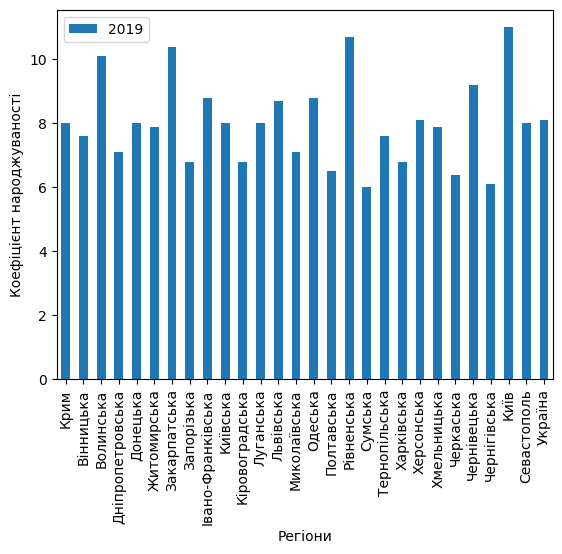

In [30]:
import matplotlib.pyplot as plt
df_plot = df[["Регіон", "2019"]]
df_plot.plot(x = "Регіон", y = "2019", kind='bar')
plt.xlabel("Регіони")
plt.ylabel("Коефіцієнт народжуваності")
plt.show()

ГРАФІКИ

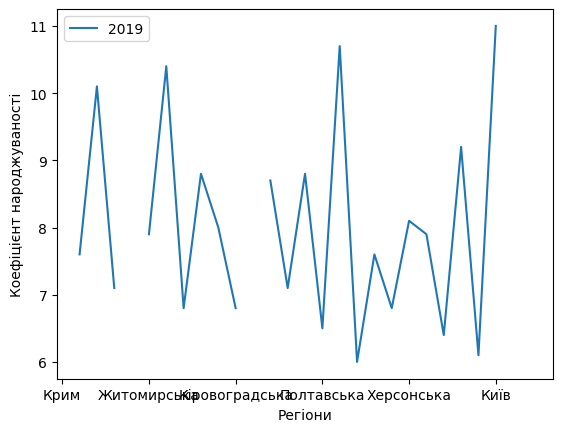

In [9]:
%matplotlib inline
df.plot(x = "Регіон", y = "2019")
plt.xlabel("Регіони")
plt.ylabel("Коефіцієнт народжуваності")
plt.show()

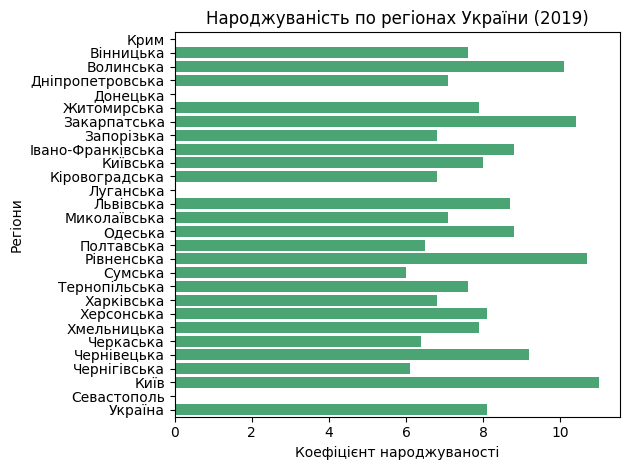

In [15]:
import seaborn as sns
plt.figure()
sns.barplot(x="2019", y="Регіон", data=df, color="mediumseagreen")
plt.xlabel("Коефіцієнт народжуваності")
plt.ylabel("Регіони")
plt.title("Народжуваність по регіонах України (2019)")
plt.tight_layout()
plt.show()

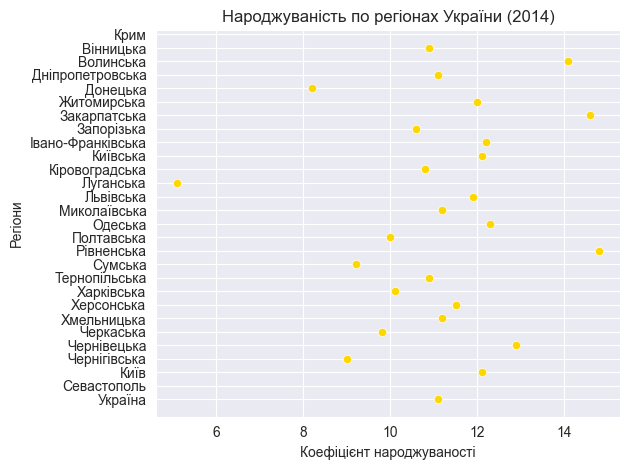

In [31]:
plt.figure()
sns.scatterplot(x="2014", y="Регіон", data=df, color="#FFD700")
plt.xlabel("Коефіцієнт народжуваності")
plt.ylabel("Регіони")
plt.title("Народжуваність по регіонах України (2014)")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

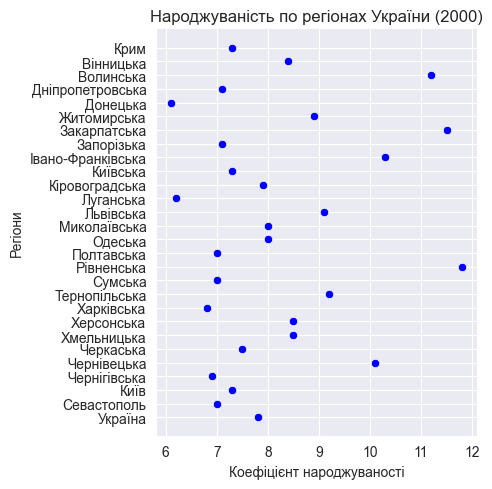

In [35]:
plt.figure()
sns.relplot(x="2000", y="Регіон", data=df, color="blue")
plt.xlabel("Коефіцієнт народжуваності")
plt.ylabel("Регіони")
plt.title("Народжуваність по регіонах України (2000)")
plt.tight_layout()
plt.show()